##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [3]:
!pip install -q keras-cv tensorflow 

import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [4]:
# Load Pretrained YOLOv8
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",  
)

In [ ]:
# Load images
image_paths = [
    "/content/lab04-object-detection/im1.jpg", # car
    "/content/lab04-object-detection/im2.jpg", # cat
    "/content/lab04-object-detection/im3.jpg", # sofa
    "/content/lab04-object-detection/im4.jpg", # person
    "/content/lab04-object-detection/im5.jpg", # bird
]

images = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

print("Loaded:", len(images))

Loaded: 5


In [11]:
inference_resizing = keras_cv.layers.Resizing(
     640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
resized_images = tf.stack([inference_resizing(tf.expand_dims(img,0))[0] for img in images]).numpy() 

In [12]:
predictions = model.predict(resized_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


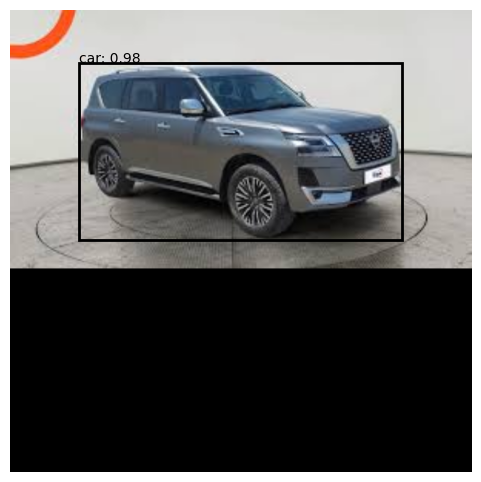

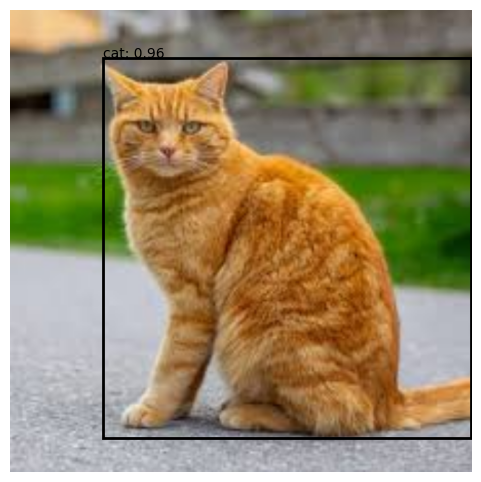

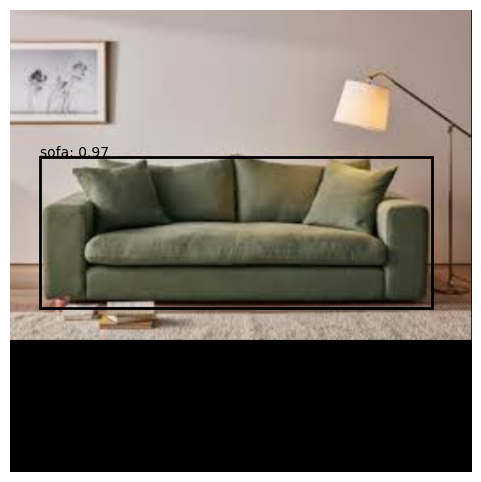

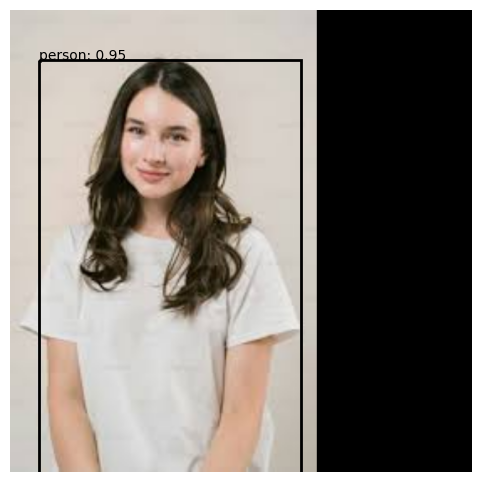

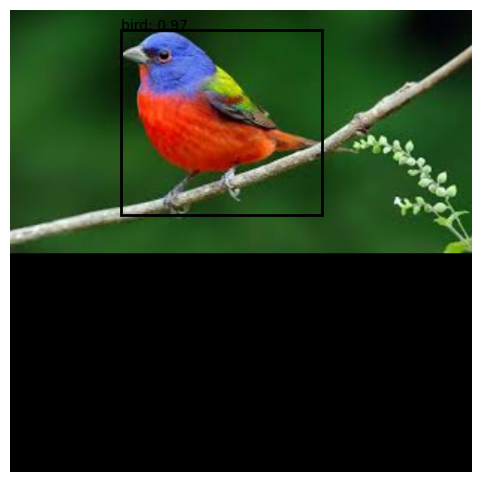

In [17]:
class_names = [
    "aeroplane","bicycle",
    "bird","boat",
    "bottle","bus",
    "car","cat",
    "chair", "cow",
    "diningtable", "dog", 
    "horse", "motorbike",
    "person", "pottedplant",
    "sheep", "sofa",
    "train", "tvmonitor",
]

class_ids = class_names

boxes_batch = predictions["boxes"]
classes_batch = predictions["classes"]
scores_batch = predictions["confidence"]

for i in range(len(resized_images)):
    
    image = resized_images[i].astype("uint8")
    boxes = boxes_batch[i]
    classes = classes_batch[i]
    scores = scores_batch[i]

    plt.figure(figsize=(6,6))
    plt.imshow(image)

    for box, cls, score in zip(boxes, classes, scores):
        if score < 0.5:
            continue

        x, y, w, h = box

        plt.gca().add_patch(
            plt.Rectangle(
                (x, y),
                w,
                h,
                fill=False,
                linewidth=2
            )
        )

        label = f"{class_ids[int(cls)]}: {float(score):.2f}"
        plt.text(x, y, label, fontsize=10)

    plt.axis("off")
    plt.show()

The summary of results:

Image 1
Ground Truth Objects:
Car
Detected Objects:
Car (Confidence: 0.98)

Image 2
Ground Truth Objects:
Cat
Detected Objects:
Cat (Confidence: 0.96)

Image 3
Ground Truth Objects:
Sofa
Detected Objects:
Sofa (Confidence: 0.97)

Image 4
Ground Truth Objects:
Person
Detected Objects:
Person (Confidence: 0.95)

Image 5
Ground Truth Objects:
bird
Detected Objects:
bird (Confidence: 0.97)